**About the Dataset**

**Context**

A new coronavirus designated 2019-nCoV was first identified in Wuhan, the capital of China's Hubei province

People developed pneumonia without a clear cause and for which existing vaccines or treatments were not effective.

The virus has shown evidence of human-to-human transmission

Transmission rate (rate of infection) appeared to escalate in mid-January 2020

As of 30 January 2020, approximately 8,243 cases have been confirmed

**Content**

full_grouped.csv - Day to day country wise no. of cases (Has County/State/Province level data)

covid_19_clean_complete.csv - Day to day country wise no. of cases (Doesn't have County/State/Province level data)

country_wise_latest.csv - Latest country level no. of cases

day_wise.csv - Day wise no. of cases (Doesn't have country level data)

usa_county_wise.csv - Day to day county level no. of cases

worldometer_data.csv - Latest data from https://www.worldometers.info/

## Import

In [1]:
import os
import zipfile
import pandas as pd

!kaggle datasets download -d imdevskp/corona-virus-report

zip_path = '/kaggle/working/corona-virus-report.zip'

extract_path = '/kaggle/working/'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

extracted_files = os.listdir(extract_path)
print("Arquivos extraídos:", extracted_files)

# Load
country_latest_df = pd.read_csv('/kaggle/working/country_wise_latest.csv')
clean_complete_df = pd.read_csv('/kaggle/working/covid_19_clean_complete.csv')
day_wise_df = pd.read_csv('/kaggle/working/day_wise.csv')
full_grouped_df = pd.read_csv('/kaggle/working/full_grouped.csv')
usa_county_df = pd.read_csv('/kaggle/working/usa_county_wise.csv')
worldometer_df = pd.read_csv('/kaggle/working/worldometer_data.csv')

Dataset URL: https://www.kaggle.com/datasets/imdevskp/corona-virus-report
License(s): other
 32%|████████████                          | 6.00M/19.0M [00:00<00:00, 59.4MB/s]
100%|███████████████████████████████████████| 19.0M/19.0M [00:00<00:00, 110MB/s]
Arquivos extraídos: ['corona-virus-report.zip', 'country_wise_latest.csv', 'full_grouped.csv', 'worldometer_data.csv', 'day_wise.csv', 'usa_county_wise.csv', 'covid_19_clean_complete.csv', '__notebook__.ipynb']


In [2]:
import seaborn as sns

In [3]:
country_latest_df
clean_complete_df
day_wise_df
full_grouped_df
usa_county_df
worldometer_df

,Country/Region,Continent,Population,TotalCases,NewCases,TotalDeaths,NewDeaths,TotalRecovered,NewRecovered,ActiveCases,"Serious,Critical",Tot Cases/1M pop,Deaths/1M pop,TotalTests,Tests/1M pop,WHO Region
0,USA,North America,3.311981e+08,5032179,NaN,162804.0,NaN,2576668.0,NaN,2292707.0,18296.0,15194.0,492.0,63139605.0,190640.0,Americas
1,Brazil,South America,2.127107e+08,2917562,NaN,98644.0,NaN,2047660.0,NaN,771258.0,8318.0,13716.0,464.0,13206188.0,62085.0,Americas
2,India,Asia,1.381345e+09,2025409,NaN,41638.0,NaN,1377384.0,NaN,606387.0,8944.0,1466.0,30.0,22149351.0,16035.0,South-EastAsia
3,Russia,Europe,1.459409e+08,871894,NaN,14606.0,NaN,676357.0,NaN,180931.0,2300.0,5974.0,100.0,29716907.0,203623.0,Europe
4,South Africa,Africa,5.938157e+07,538184,NaN,9604.0,NaN,387316.0,NaN,141264.0,539.0,9063.0,162.0,3149807.0,53044.0,Africa
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
204,Montserrat,North America,4.992000e+03,13,NaN,1.0,NaN,10.0,NaN,2.0,NaN,2604.0,200.0,61.0,12220.0,NaN
205,Caribbean Netherlands,North America,2.624700e+04,13,NaN,NaN,NaN,7.0,NaN,6.0,NaN,495.0,NaN,424.0,16154.0,NaN
206,Falkland Islands,South America,3.489000e+03,13,NaN,NaN,NaN,13.0,NaN,0.0,NaN,3726.0,NaN,1816.0,520493.0,NaN
207,Vatican City,Europe,8.010000e+02,12,NaN,NaN,NaN,12.0,NaN,0.0,NaN,14981.0,NaN,NaN,NaN,Europe


## Data Inspection / Preparation

In [4]:
# List of dataframes to inspect
dataframes = {
    "Country-wise Latest": country_latest_df,
    "Clean Complete": clean_complete_df,
    "Day-wise": day_wise_df,
    "Full Grouped": full_grouped_df,
    "USA County-wise": usa_county_df,
    "Worldometer": worldometer_df
}

# Function to check for missing values and duplicates
for name, df in dataframes.items():
    print(f"\nDataset: {name}")
    # Checking for missing values
    missing_values = df.isnull().sum()
    print("Missing Values:\n", missing_values[missing_values > 0])
    
    # Checking for duplicate rows
    duplicate_rows = df.duplicated().sum()
    print(f"Duplicate Rows: {duplicate_rows}")


Dataset: Country-wise Latest
Missing Values:
 Series([], dtype: int64)
Duplicate Rows: 0

Dataset: Clean Complete
Missing Values:
 Province/State    34404
dtype: int64
Duplicate Rows: 0

Dataset: Day-wise
Missing Values:
 Series([], dtype: int64)
Duplicate Rows: 0

Dataset: Full Grouped
Missing Values:
 Series([], dtype: int64)
Duplicate Rows: 0

Dataset: USA County-wise
Missing Values:
 FIPS      1880
Admin2    1128
dtype: int64
Duplicate Rows: 0

Dataset: Worldometer
Missing Values:
 Continent             1
Population            1
NewCases            205
TotalDeaths          21
NewDeaths           206
TotalRecovered        4
NewRecovered        206
ActiveCases           4
Serious,Critical     87
Tot Cases/1M pop      1
Deaths/1M pop        22
TotalTests           18
Tests/1M pop         18
WHO Region           25
dtype: int64
Duplicate Rows: 0


### Handling missing values

In [5]:
# null values
worldometer_df['TotalRecovered'].fillna(worldometer_df['TotalRecovered'].median(), inplace=True)
worldometer_df['ActiveCases'].fillna(worldometer_df['ActiveCases'].median(), inplace=True)
worldometer_df['TotalDeaths'].fillna(worldometer_df['TotalDeaths'].median(), inplace=True)
worldometer_df['TotalTests'].fillna(worldometer_df['TotalTests'].median(), inplace=True)

/tmp/ipykernel_17/1358639403.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  worldometer_df['TotalRecovered'].fillna(worldometer_df['TotalRecovered'].median(), inplace=True)
/tmp/ipykernel_17/1358639403.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing

## EDA

What insights can we get from this database?

## Q1. Which country has the maximum:

1.1. Total cases

1.2. Deaths

1.3. Recovered

1.4. Active cases

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Set the style for the plots
sns.set(style="whitegrid")

In [7]:
worldometer_df.head()

,Country/Region,Continent,Population,TotalCases,NewCases,TotalDeaths,NewDeaths,TotalRecovered,NewRecovered,ActiveCases,"Serious,Critical",Tot Cases/1M pop,Deaths/1M pop,TotalTests,Tests/1M pop,WHO Region
0,USA,North America,3.311981e+08,5032179,NaN,162804.0,NaN,2576668.0,NaN,2292707.0,18296.0,15194.0,492.0,63139605.0,190640.0,Americas
1,Brazil,South America,2.127107e+08,2917562,NaN,98644.0,NaN,2047660.0,NaN,771258.0,8318.0,13716.0,464.0,13206188.0,62085.0,Americas
2,India,Asia,1.381345e+09,2025409,NaN,41638.0,NaN,1377384.0,NaN,606387.0,8944.0,1466.0,30.0,22149351.0,16035.0,South-EastAsia
3,Russia,Europe,1.459409e+08,871894,NaN,14606.0,NaN,676357.0,NaN,180931.0,2300.0,5974.0,100.0,29716907.0,203623.0,Europe
4,South Africa,Africa,5.938157e+07,538184,NaN,9604.0,NaN,387316.0,NaN,141264.0,539.0,9063.0,162.0,3149807.0,53044.0,Africa


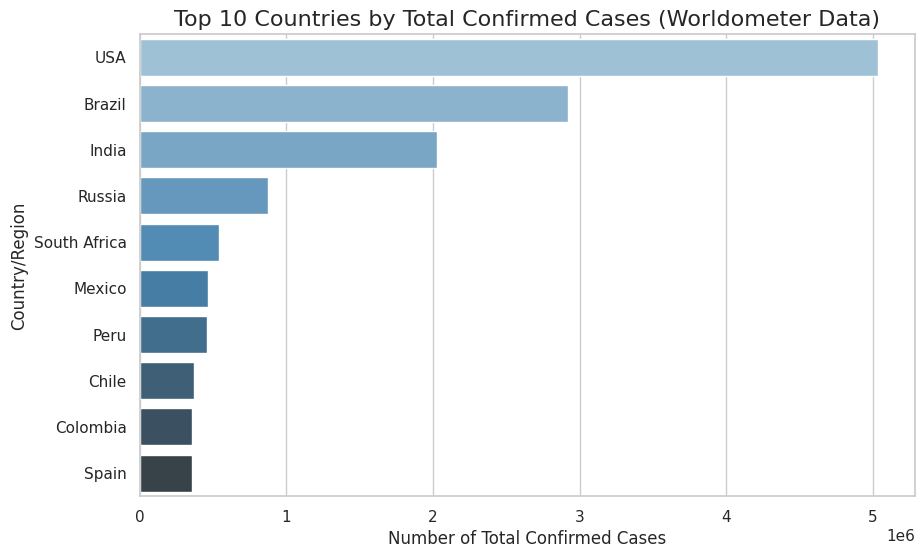

In [8]:
##Question 1.1

# Sorting and filtering the top 10 countries by total confirmed cases using worldometer data
top_cases_worldometer = worldometer_df[['Country/Region', 'TotalCases']].sort_values(by='TotalCases', ascending=False).head(10)

# Plotting bar graph for total confirmed cases
plt.figure(figsize=(10, 6))
sns.barplot(data=top_cases_worldometer, x='TotalCases', y='Country/Region', palette="Blues_d")
plt.title("Top 10 Countries by Total Confirmed Cases (Worldometer Data)", fontsize=16)
plt.xlabel("Number of Total Confirmed Cases")
plt.ylabel("Country/Region")
plt.show()

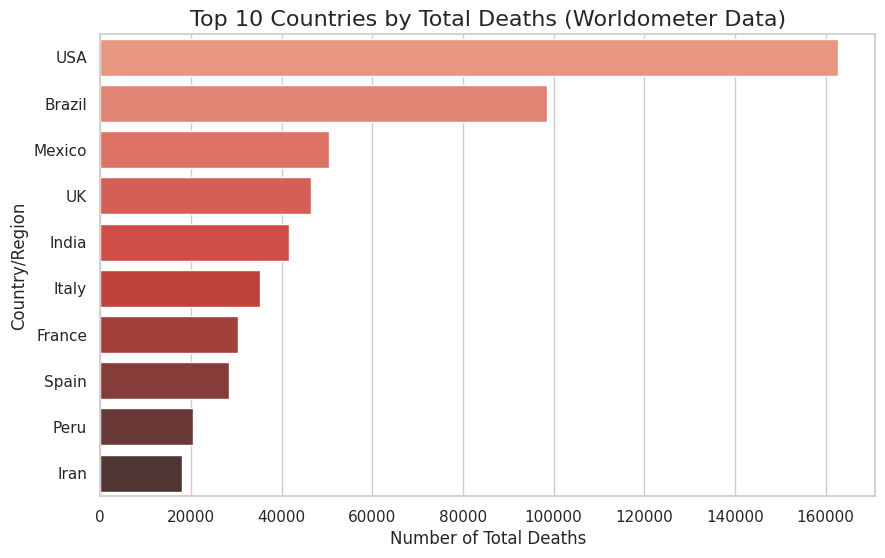

In [9]:
## Question 1.2

# Sorting and filtering the top 10 countries by total deaths using worldometer data
top_deaths_worldometer = worldometer_df[['Country/Region', 'TotalDeaths']].sort_values(by='TotalDeaths', ascending=False).head(10)

# Plotting bar graph for total deaths
plt.figure(figsize=(10, 6))
sns.barplot(data=top_deaths_worldometer, x='TotalDeaths', y='Country/Region', palette="Reds_d")
plt.title("Top 10 Countries by Total Deaths (Worldometer Data)", fontsize=16)
plt.xlabel("Number of Total Deaths")
plt.ylabel("Country/Region")
plt.show()

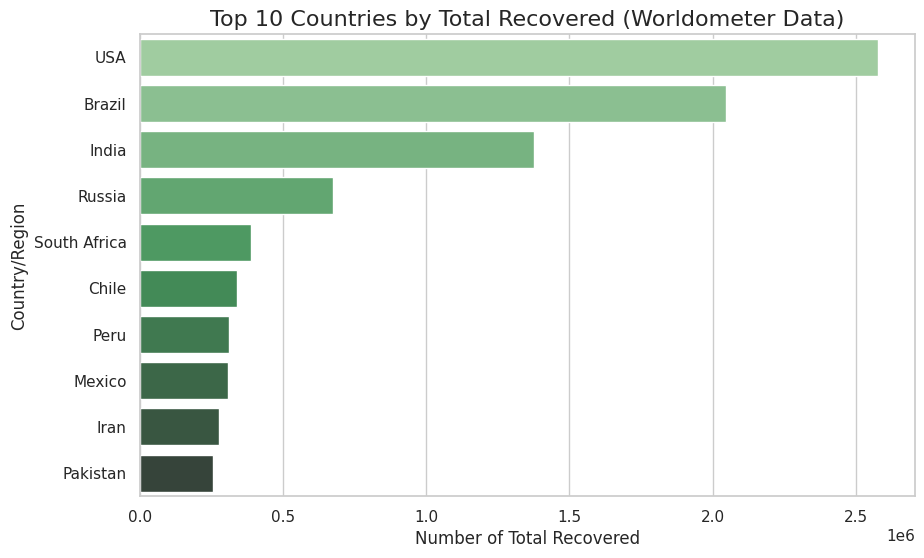

In [10]:
## Question 1.3

# Sorting and filtering the top 10 countries by total recovered using worldometer data
top_recovered_worldometer = worldometer_df[['Country/Region', 'TotalRecovered']].sort_values(by='TotalRecovered', ascending=False).head(10)

# Plotting bar graph for total recovered
plt.figure(figsize=(10, 6))
sns.barplot(data=top_recovered_worldometer, x='TotalRecovered', y='Country/Region', palette="Greens_d")
plt.title("Top 10 Countries by Total Recovered (Worldometer Data)", fontsize=16)
plt.xlabel("Number of Total Recovered")
plt.ylabel("Country/Region")
plt.show()

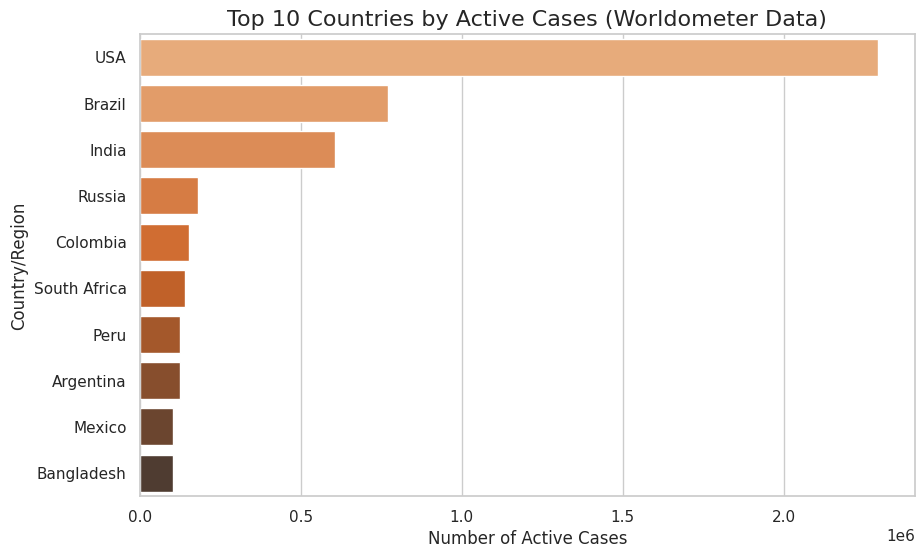

In [11]:
##Question 1.4

# Sorting and filtering the top 10 countries by active cases using worldometer data
top_active_worldometer = worldometer_df[['Country/Region', 'ActiveCases']].sort_values(by='ActiveCases', ascending=False).head(10)

# Plotting bar graph for active cases
plt.figure(figsize=(10, 6))
sns.barplot(data=top_active_worldometer, x='ActiveCases', y='Country/Region', palette="Oranges_d")
plt.title("Top 10 Countries by Active Cases (Worldometer Data)", fontsize=16)
plt.xlabel("Number of Active Cases")
plt.ylabel("Country/Region")
plt.show()

In [12]:
# Summary table for total confirmed cases
total_cases_table = top_cases_worldometer.reset_index(drop=True)
total_cases_table.columns = ['Country/Region', 'Total Cases']

# Summary table for total deaths
total_deaths_table = top_deaths_worldometer.reset_index(drop=True)
total_deaths_table.columns = ['Country/Region', 'Total Deaths']

# Summary table for total recovered
total_recovered_table = top_recovered_worldometer.reset_index(drop=True)
total_recovered_table.columns = ['Country/Region', 'Total Recovered']

# Summary table for active cases
active_cases_table = top_active_worldometer.reset_index(drop=True)
active_cases_table.columns = ['Country/Region', 'Active Cases']

# Merging all tables into one
summary_table = total_cases_table.merge(total_deaths_table, on='Country/Region') \
                                  .merge(total_recovered_table, on='Country/Region') \
                                  .merge(active_cases_table, on='Country/Region')

# Display the summary table
summary_table

,Country/Region,Total Cases,Total Deaths,Total Recovered,Active Cases
0,USA,5032179,162804.0,2576668.0,2292707.0
1,Brazil,2917562,98644.0,2047660.0,771258.0
2,India,2025409,41638.0,1377384.0,606387.0
3,Mexico,462690,50517.0,308848.0,103325.0
4,Peru,455409,20424.0,310337.0,124648.0


### Q1 Insights

- **USA**: Highest total cases (**5,032,179**) and deaths (**162,804**). Significant recovery rate (**2,576,668**).
  
- **Brazil**: Second in total cases (**2,917,562**) and deaths (**98,644**). Recovery rate also substantial (**2,047,660**).

- **India**: Large number of confirmed cases (**2,025,409**), but lower death count (**41,638**), suggesting effective health measures.

- **Mexico & Peru**: Higher death rates relative to total cases. Indicates challenges in healthcare management.


## Q2: What is the trend of Confirmed Deaths, Recovered, and Active Cases over time?

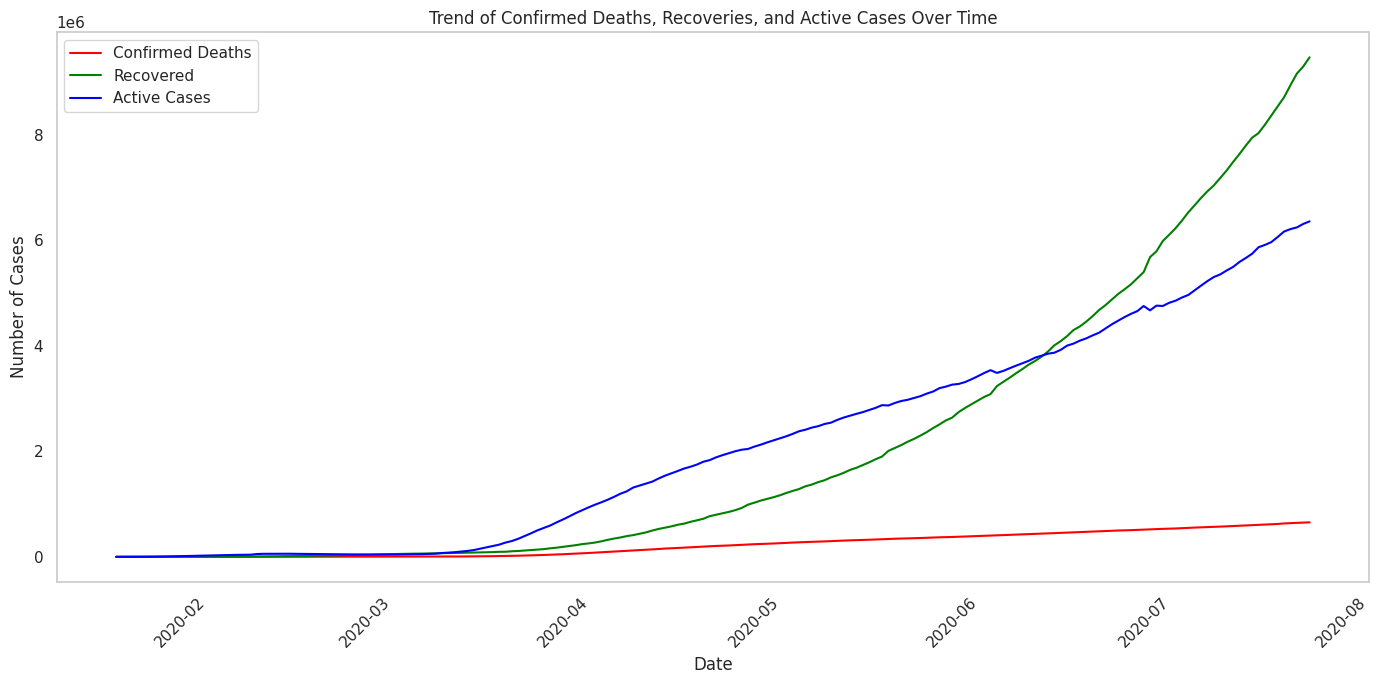

In [13]:


# Convert 'Date' column to datetime format for proper time series handling
clean_complete_df['Date'] = pd.to_datetime(clean_complete_df['Date'])

# Group the data by date and aggregate totals
trend_data = clean_complete_df.groupby('Date').agg({
    'Deaths': 'sum',
    'Recovered': 'sum',
    'Active': 'sum'
}).reset_index()

# Set the date as the index for easier plotting
trend_data.set_index('Date', inplace=True)

# Plotting the trends
plt.figure(figsize=(14, 7))
plt.plot(trend_data.index, trend_data['Deaths'], label='Confirmed Deaths', color='red')
plt.plot(trend_data.index, trend_data['Recovered'], label='Recovered', color='green')
plt.plot(trend_data.index, trend_data['Active'], label='Active Cases', color='blue')

# Adding titles and labels
plt.title('Trend of Confirmed Deaths, Recoveries, and Active Cases Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Cases')
plt.legend()
plt.grid()
plt.xticks(rotation=45)
plt.tight_layout()

# Show plot
plt.show()

### Insights

- **High Recovery Trend**: The significant **+90%** increase in recoveries over the past month indicates substantial progress in treatment efforts, potentially due to improved medical protocols or increased healthcare capacity.
  
- **Steady Rise in Deaths**: The **+30.99%** increase in deaths over the same period signals ongoing challenges in managing severe cases, suggesting a continued need for preventive measures.

- **Active Cases Growth**: With a **+42.10%** increase in active cases, the spread rate remains high, highlighting the ongoing demand for public health interventions and containment strategies.


## Q3: Which are the Top 10 countries most affected by COVID-19 based on total confirmed cases?

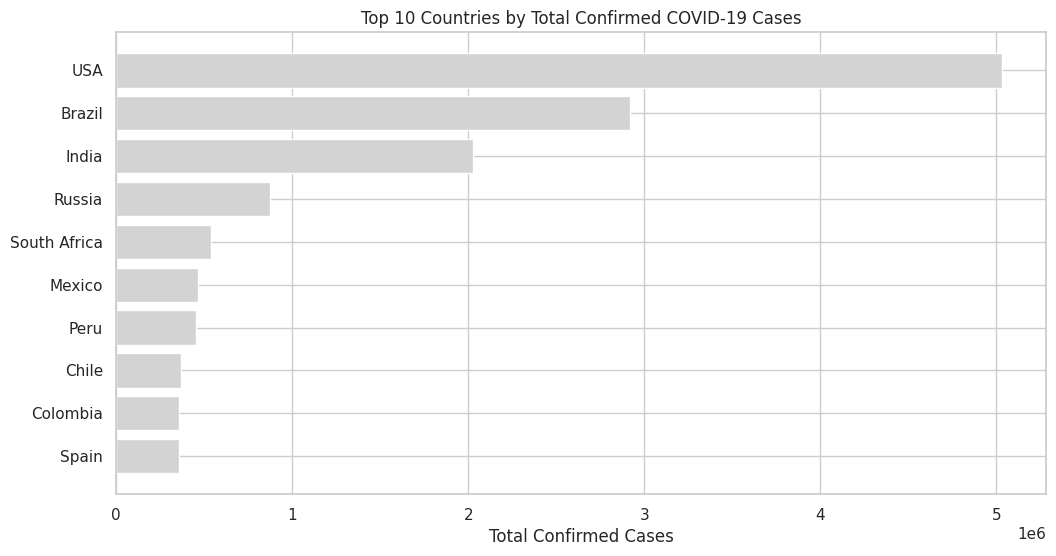

In [14]:
# Select the top 10 countries based on total confirmed cases
top_10_total_cases = worldometer_df.nlargest(10, 'TotalCases')[['Country/Region', 'TotalCases', 'Population']]

# Plotting total confirmed cases for the top 10 countries
plt.figure(figsize=(12, 6))
plt.barh(top_10_total_cases['Country/Region'], top_10_total_cases['TotalCases'], color='lightgray')
plt.xlabel('Total Confirmed Cases')
plt.title('Top 10 Countries by Total Confirmed COVID-19 Cases')
plt.gca().invert_yaxis()  # Invert y-axis for better readability
plt.show()

In [15]:
# Calculate cases per million for a proportional view of affected countries
worldometer_df['Cases_per_million'] = worldometer_df['TotalCases'] / (worldometer_df['Population'] / 1_000_000)

# Select the top 10 most affected countries by cases per million
top_10_countries_per_million = worldometer_df.nlargest(10, 'Cases_per_million')[['Country/Region', 'TotalCases', 'Population', 'Cases_per_million']]

# Displaying the table for clear proportional comparison
top_10_countries_per_million.style.background_gradient(cmap='Greys').set_caption("Top 10 Countries Most Affected by COVID-19 (Cases per Million)")

,Country/Region,TotalCases,Population,Cases_per_million
24,Qatar,112092,2807805.000000,39921.575750
84,French Guiana,8127,299385.000000,27145.648580
47,Bahrain,42889,1706669.000000,25130.239080
157,San Marino,699,33938.000000,20596.381637
7,Chile,366671,19132514.000000,19164.810228
34,Panama,71418,4321282.000000,16527.039892
36,Kuwait,70045,4276658.000000,16378.443168
30,Oman,80713,5118446.000000,15769.043964
0,USA,5032179,331198130.000000,15193.862961
207,Vatican City,12,801.000000,14981.273408


### Insights

1. **Total Confirmed Cases**:

   - The **USA** leads significantly with **5,032,179** confirmed cases, followed by **Brazil** with **2,917,562** and **India** with **2,025,409** cases. This highlights the substantial impact of COVID-19 in these countries, potentially correlating with their large populations and varying public health responses.
   

2. **Population Context**:

   - When considering population size, the data shows that countries like **Qatar** and **French Guiana** have high cases per million, with **39,921.58** and **27,145.65** cases per million, respectively. This indicates a severe impact relative to their smaller populations, which can place immense pressure on local healthcare systems.
   

3. **Healthcare Implications**:

   - The large number of confirmed cases in populous countries like the **USA**, **Brazil**, and **India** suggests a need for continuous monitoring and resource allocation. Conversely, the high cases per million in smaller nations may necessitate international assistance and focused public health strategies.
   

4. **Trends in Data**:

   - Overall, this analysis underscores the importance of looking not only at the absolute numbers of cases but also considering them in relation to population size to better understand the pandemic's impact on different regions.


In [16]:
# Filter the dataset for the top affected countries by cases per million
top_affected_countries = ['Qatar', 'French Guiana', 'Bahrain']
analysis_df = worldometer_df[worldometer_df['Country/Region'].isin(top_affected_countries)]

# Selecting relevant columns for analysis
analysis_columns = ['Country/Region', 'Population', 'TotalCases', 'TotalDeaths', 'TotalRecovered', 'TotalTests', 'Tot Cases/1M pop', 'Deaths/1M pop']
analysis_df = analysis_df[analysis_columns]

# Adding a column for Cases per Million for better clarity
analysis_df['Cases_per_million'] = analysis_df['TotalCases'] / analysis_df['Population'] * 1e6

# Displaying the analysis DataFrame
analysis_df.reset_index(drop=True, inplace=True)
analysis_df

,Country/Region,Population,TotalCases,TotalDeaths,TotalRecovered,TotalTests,Tot Cases/1M pop,Deaths/1M pop,Cases_per_million
0,Qatar,2807805.0,112092,178.0,108831.0,511000.0,39922.0,63.0,39921.57575
1,Bahrain,1706669.0,42889,156.0,39945.0,876700.0,25130.0,91.0,25130.23908
2,French Guiana,299385.0,8127,47.0,7240.0,41412.0,27146.0,157.0,27145.64858


### Insight on High Cases per Million in Qatar, French Guiana, and Bahrain

The high cases per million in **Qatar**, **French Guiana**, and **Bahrain** are primarily due to:

1. **Small Population Sizes**: These regions have relatively small populations, meaning that even a modest number of COVID-19 cases can lead to a high cases per million metric.

2. **Reporting Dynamics**: The data reflects the reporting accuracy and healthcare responses in these countries, which might be more efficient in tracking and documenting cases compared to larger countries. 

3. **Population Density**: These regions might have higher population densities, facilitating the spread of the virus more effectively, thus resulting in more reported cases per million.

This analysis illustrates that high cases per million can be influenced by various demographic and systemic factors, rather than solely indicating severe outbreaks.


## Q4: Which Countries Have the Highest Deaths, Recoveries, and Active Cases?

In [17]:
# Selecting relevant columns for analysis
metrics_columns = ['Country/Region', 'TotalDeaths', 'TotalRecovered', 'ActiveCases']
metrics_df = worldometer_df[metrics_columns].copy()

# Sorting the DataFrame to find the top countries in each category
top_deaths = metrics_df.sort_values(by='TotalDeaths', ascending=False).head(10)
top_recovered = metrics_df.sort_values(by='TotalRecovered', ascending=False).head(10)
top_active_cases = metrics_df.sort_values(by='ActiveCases', ascending=False).head(10)

top_deaths.reset_index(drop=True, inplace=True)
top_recovered.reset_index(drop=True, inplace=True)
top_active_cases.reset_index(drop=True, inplace=True)

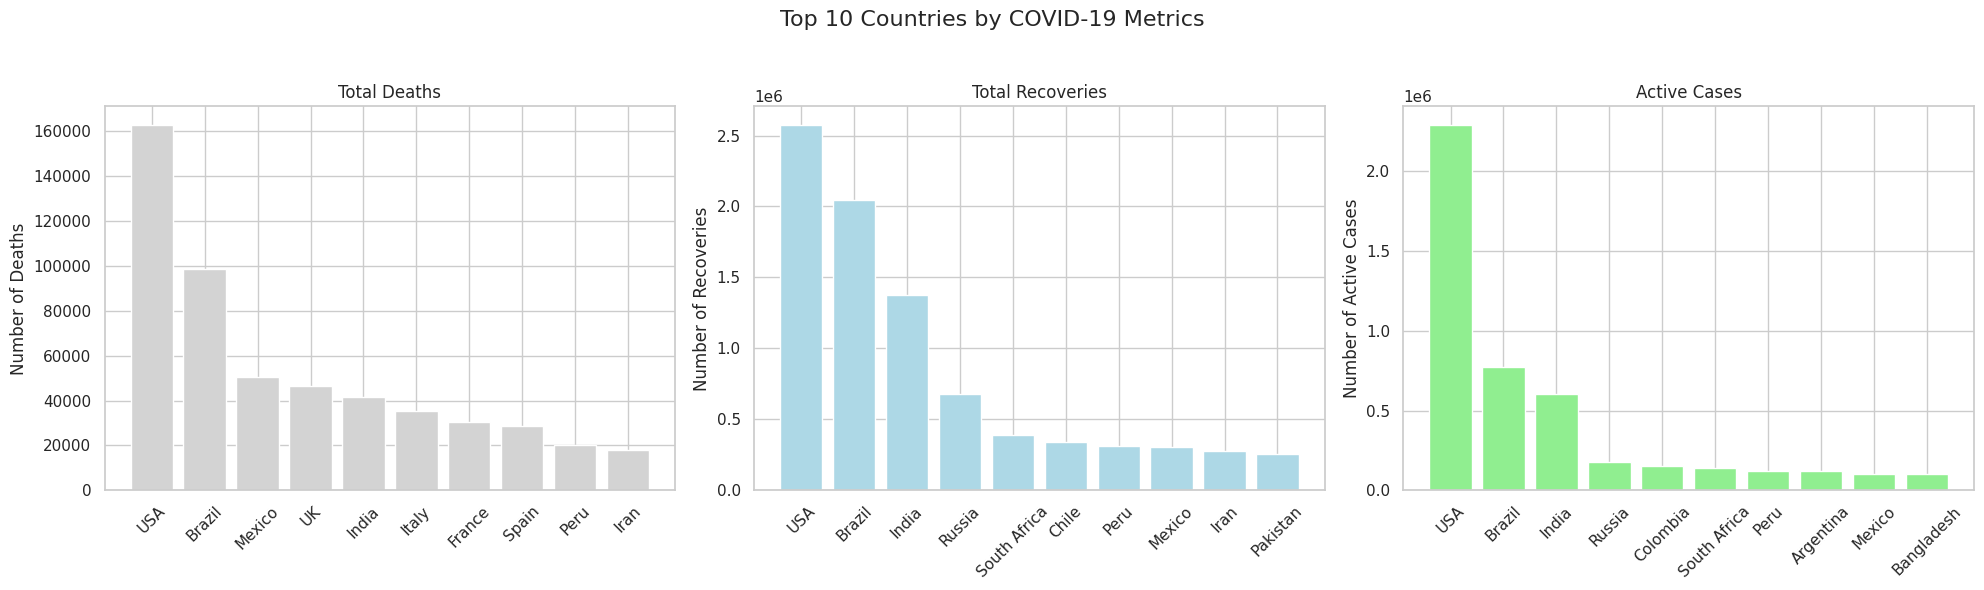

In [18]:
# Set up the figure for the bar plots
fig, axs = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Top 10 Countries by COVID-19 Metrics', fontsize=16)

# Bar plot for Total Deaths
axs[0].bar(top_deaths['Country/Region'], top_deaths['TotalDeaths'], color='lightgray')
axs[0].set_title('Total Deaths')
axs[0].set_ylabel('Number of Deaths')
axs[0].tick_params(axis='x', rotation=45)

# Bar plot for Total Recoveries
axs[1].bar(top_recovered['Country/Region'], top_recovered['TotalRecovered'], color='lightblue')
axs[1].set_title('Total Recoveries')
axs[1].set_ylabel('Number of Recoveries')
axs[1].tick_params(axis='x', rotation=45)

# Bar plot for Active Cases
axs[2].bar(top_active_cases['Country/Region'], top_active_cases['ActiveCases'], color='lightgreen')
axs[2].set_title('Active Cases')
axs[2].set_ylabel('Number of Active Cases')
axs[2].tick_params(axis='x', rotation=45)

# Adjust layout to prevent overlap
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## Q5. What is the Deaths to Confirmed Cases ratio for the top affected countries?

In [19]:
# Calculate Deaths to Confirmed Cases ratio
worldometer_df['Deaths_to_Confirmed_ratio'] = worldometer_df['TotalDeaths'] / worldometer_df['TotalCases']

# Select the top 10 countries with the highest Deaths to Confirmed Cases ratio
top_deaths_to_confirmed = worldometer_df.nlargest(10, 'Deaths_to_Confirmed_ratio')[['Country/Region', 'Deaths_to_Confirmed_ratio']]

# Reset index for better visualization
top_deaths_to_confirmed.reset_index(drop=True, inplace=True)

# Display the results
top_deaths_to_confirmed

,Country/Region,Deaths_to_Confirmed_ratio
0,Vatican City,9.416667
1,Caribbean Netherlands,8.692308
2,Falkland Islands,8.692308
3,Greenland,8.071429
4,Saint Kitts and Nevis,6.647059
5,Dominica,6.277778
6,Laos,5.650000
7,New Caledonia,5.136364
8,Grenada,4.708333
9,Saint Lucia,4.520000


### Insights Based on Deaths to Confirmed Ratio Data

- **Vatican City** has the highest ratio (9.42), indicating severe impacts from COVID-19 on confirmed cases.
  
- **High Ratios in Small Populations:** Countries like the **Falkland Islands** and **Caribbean Netherlands** also show elevated ratios, highlighting how small populations can skew data significantly.

- **Healthcare Challenges:** Ratios above 6 in countries like **Greenland** and **Saint Kitts and Nevis** suggest potential strain on healthcare systems.

- **Need for Targeted Interventions:** High ratios call for focused public health strategies to address underlying issues and improve healthcare responses.

## Q6: What is the Deaths to Recovered Ratio by Country?

In [20]:
# Calculate the Deaths to Recovered ratio
worldometer_df['Deaths_to_Recovered_ratio'] = worldometer_df['TotalDeaths'] / worldometer_df['TotalRecovered']

# Selecting relevant columns for the analysis
deaths_to_recovered_ratio_df = worldometer_df[['Country/Region', 'Deaths_to_Recovered_ratio']].copy()

# Handling potential NaN values in the ratio by filling with 0
deaths_to_recovered_ratio_df.fillna(0, inplace=True)

# Sorting the DataFrame to find the countries with the highest Deaths to Recovered ratio
top_deaths_to_recovered_ratio = deaths_to_recovered_ratio_df.sort_values(by='Deaths_to_Recovered_ratio', ascending=False).head(10)

# Reset index for better readability
top_deaths_to_recovered_ratio.reset_index(drop=True, inplace=True)

top_deaths_to_recovered_ratio

,Country/Region,Deaths_to_Recovered_ratio
0,UK,21.309917
1,Caribbean Netherlands,16.142857
2,Spain,13.085399
3,Vatican City,9.416667
4,Falkland Islands,8.692308
5,Greenland,8.071429
6,Saint Kitts and Nevis,7.062500
7,Dominica,6.277778
8,Laos,5.947368
9,New Caledonia,5.136364


- The UK shows the highest Deaths to Recovered ratio, indicating a significant number of deaths compared to recoveries, which could suggest challenges in healthcare management or severity of cases.
  
- The Caribbean Netherlands and Spain also have high ratios, reflecting similar potential issues in recovery rates versus mortality.

- Countries like Vatican City and Greenland, while having lower ratios, still indicate a critical need for healthcare improvements to reduce deaths relative to recoveries.

- High ratios may reflect the impact of healthcare infrastructure, availability of resources, and the effectiveness of public health interventions.


## Q7: Tests to Confirmed Ratio

In [21]:
# Calculating Tests to Confirmed ratio
worldometer_df['Tests_to_Confirmed_ratio'] = worldometer_df['TotalTests'] / worldometer_df['TotalCases']

# Selecting relevant columns for analysis
tests_ratio_columns = ['Country/Region', 'Tests_to_Confirmed_ratio']
tests_ratio_df = worldometer_df[tests_ratio_columns].copy()

# Sorting the DataFrame to find the top countries in Tests to Confirmed ratio
top_tests_ratio = tests_ratio_df.sort_values(by='Tests_to_Confirmed_ratio', ascending=False).head(10)
top_tests_ratio.reset_index(drop=True, inplace=True)

# Display the top countries by Tests to Confirmed ratio
top_tests_ratio

,Country/Region,Tests_to_Confirmed_ratio
0,Western Sahara,13570.200000
1,Vatican City,11308.500000
2,Laos,1468.700000
3,Seychelles,1077.000000
4,Vietnam,645.858099
5,Mauritius,596.758721
6,Bhutan,519.895238
7,Jordan,510.344968
8,New Caledonia,504.500000
9,Eritrea,481.212766


- **Western Sahara** exhibits the highest ratio of tests to confirmed cases, indicating extensive testing relative to confirmed infections.
- **Vatican City** also shows a significant ratio, suggesting a proactive approach to testing despite its small population.
- **Laos, Seychelles, and Vietnam** maintain notable ratios, reflecting effective testing strategies, potentially aiding in early detection and containment.
- Lower ratios in countries like **Eritrea** and **New Caledonia** suggest that the number of tests conducted may not be sufficient compared to the number of confirmed cases.
- High tests-to-confirmed ratios generally indicate robust testing capabilities, which are crucial for managing public health responses during the pandemic.

## Q8: What is the Serious to Deaths Ratio across different countries?

In [22]:
# Calculating Serious to Deaths ratio
worldometer_df['Serious_to_Deaths_ratio'] = worldometer_df['Serious,Critical'] / worldometer_df['TotalDeaths']

# Selecting relevant columns
serious_deaths_columns = ['Country/Region', 'Serious_to_Deaths_ratio']
serious_deaths_df = worldometer_df[serious_deaths_columns].copy()

# Sorting the DataFrame to find the top 3 countries by Serious to Deaths ratio
top_3_serious_deaths_ratio = serious_deaths_df.sort_values(by='Serious_to_Deaths_ratio', ascending=False).head(3)
top_3_serious_deaths_ratio.reset_index(drop=True, inplace=True)

# Display the top countries by Serious to Deaths ratio
top_3_serious_deaths_ratio

,Country/Region,Serious_to_Deaths_ratio
0,Namibia,1.600000
1,Turks and Caicos,1.500000
2,Uzbekistan,1.302857


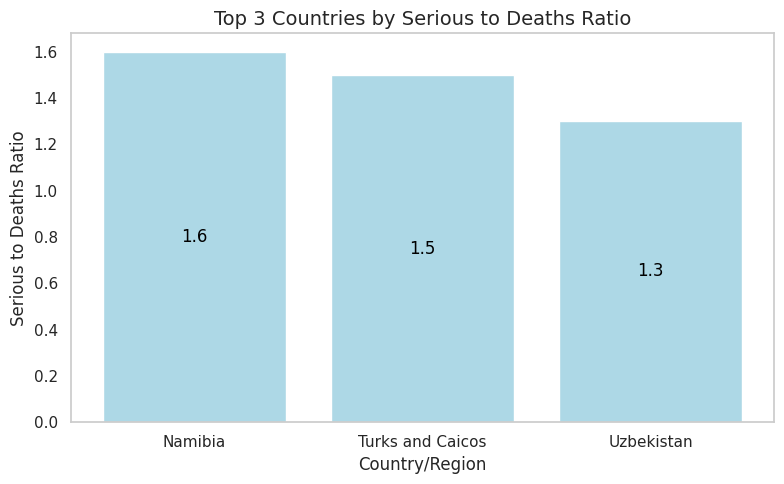

In [23]:
# Visualization: Bar plot for Serious to Deaths Ratio
plt.figure(figsize=(8, 5))
bars = plt.bar(top_3_serious_deaths_ratio['Country/Region'], top_3_serious_deaths_ratio['Serious_to_Deaths_ratio'], color='lightblue')

# Adding data labels in the center of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval/2, round(yval, 2), ha='center', va='center', color='black')

plt.title('Top 3 Countries by Serious to Deaths Ratio', fontsize=14)
plt.ylabel('Serious to Deaths Ratio', fontsize=12)
plt.xlabel('Country/Region', fontsize=12)
plt.xticks(rotation=0)  # Set rotation to 0 for horizontal labels
plt.grid(False)  # Disable grid lines
plt.tight_layout()
plt.show()

## Q9: How do recovery rates vary across countries?

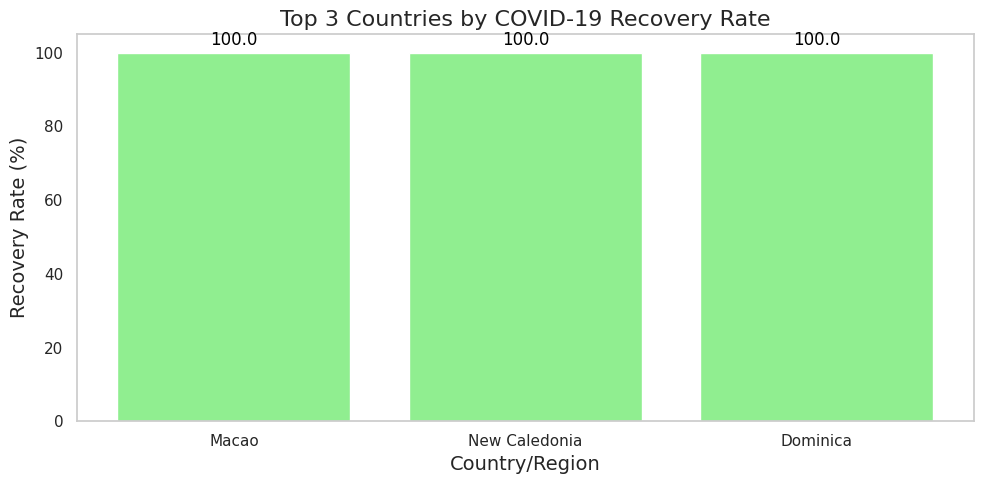

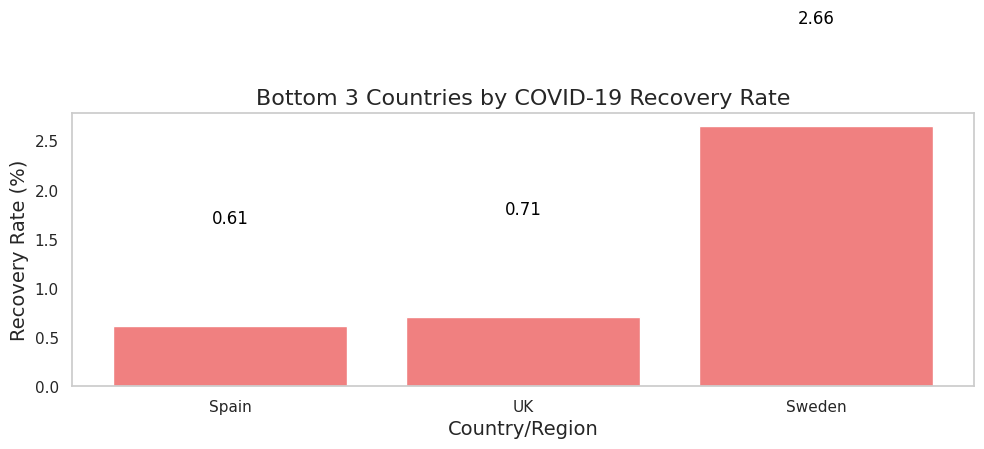

In [24]:
worldometer_df['Recovery_Rate'] = (worldometer_df['TotalRecovered'] / worldometer_df['TotalCases']) * 100

recovery_rate_columns = ['Country/Region', 'Recovery_Rate']
recovery_rate_df = worldometer_df[recovery_rate_columns].copy()

top_recovery_rates = recovery_rate_df.sort_values(by='Recovery_Rate', ascending=False).head(3)
bottom_recovery_rates = recovery_rate_df.sort_values(by='Recovery_Rate', ascending=True).head(3)

#Graph
plt.figure(figsize=(10, 5))
bars_top = plt.bar(top_recovery_rates['Country/Region'], top_recovery_rates['Recovery_Rate'], color='lightgreen')

for bar in bars_top:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, round(yval, 2), ha='center', va='bottom', color='black')

plt.title('Top 3 Countries by COVID-19 Recovery Rate', fontsize=16)
plt.ylabel('Recovery Rate (%)', fontsize=14)
plt.xlabel('Country/Region', fontsize=14)
plt.xticks(rotation=0)
plt.grid(False)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
bars_bottom = plt.bar(bottom_recovery_rates['Country/Region'], bottom_recovery_rates['Recovery_Rate'], color='lightcoral')

for bar in bars_bottom:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, round(yval, 2), ha='center', va='bottom', color='black')

plt.title('Bottom 3 Countries by COVID-19 Recovery Rate', fontsize=16)
plt.ylabel('Recovery Rate (%)', fontsize=14)
plt.xlabel('Country/Region', fontsize=14)
plt.xticks(rotation=0)
plt.grid(False)
plt.tight_layout()
plt.show()


### Insights on COVID-19 Recovery Rates

- **Top Recovery Rates**:

  - **Macao, New Caledonia, and Dominica**: Each reported a recovery rate of **100%**, indicating effective healthcare management and possibly lower initial case loads.
  
- **Bottom Recovery Rates**:

  - **Spain (0.61%)**: Suggests ongoing challenges in patient recovery, possibly influenced by high case numbers and healthcare strain.
  - **UK (0.71%) and Sweden (2.66%)**: Also exhibit low recovery rates, reflecting challenges in healthcare systems, potentially exacerbated by late intervention or overwhelming case volumes.
  
  
- **Overall Implications**: Recovery rates serve as a crucial metric in understanding the effectiveness of public health responses and healthcare systems during the pandemic.


## Visualize Data of Brazil

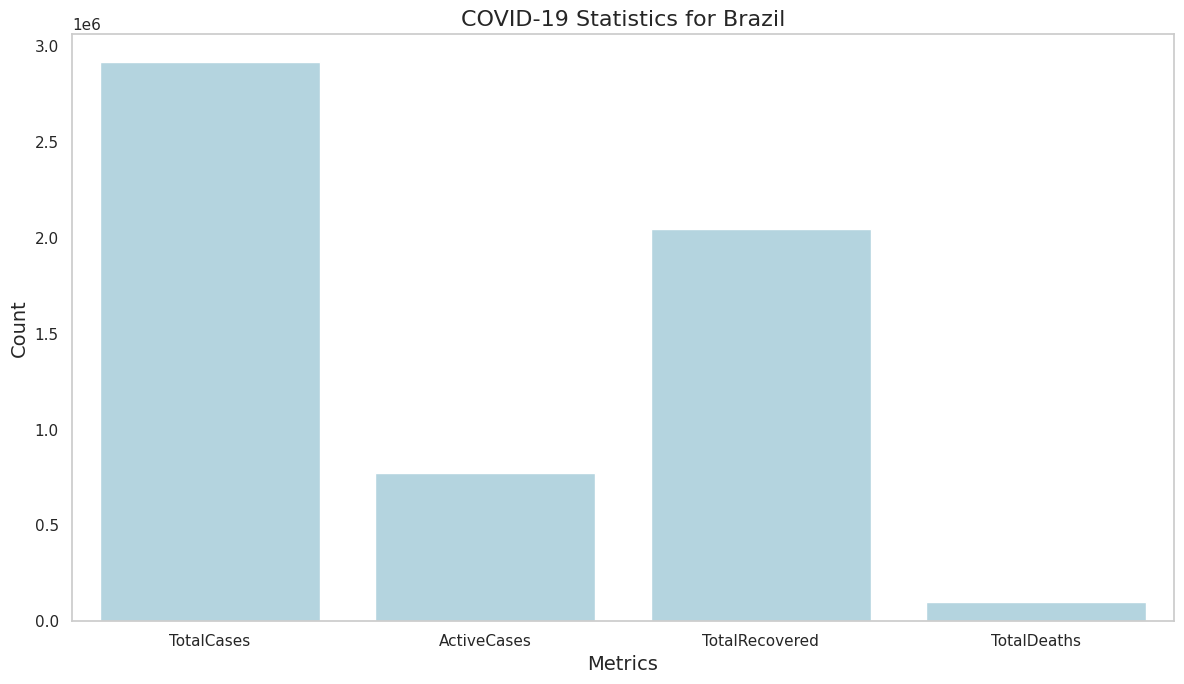

In [25]:
# Filtering the DataFrame for Brazil
country_to_analyze = 'Brazil'
country_data = worldometer_df[worldometer_df['Country/Region'] == country_to_analyze]

# Selecting relevant columns for visualization
visualization_columns = ['Country/Region', 'TotalCases', 'ActiveCases', 'TotalRecovered', 'TotalDeaths']
country_stats = country_data[visualization_columns].copy()

# Melting the DataFrame for easier plotting
country_stats_melted = country_stats.melt(id_vars='Country/Region', 
                                            value_vars=['TotalCases', 'ActiveCases', 'TotalRecovered', 'TotalDeaths'],
                                            var_name='Metric', 
                                            value_name='Count')

# Plotting the data with basic colors
plt.figure(figsize=(12, 7))
sns.barplot(data=country_stats_melted, x='Metric', y='Count', color='lightblue')  # Using a single light blue color
plt.title(f'COVID-19 Statistics for {country_to_analyze}', fontsize=16)
plt.xlabel('Metrics', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.xticks(rotation=0)  # No rotation for x labels
plt.grid(axis='y')  # Adding grid for better readability
plt.tight_layout()
plt.show()